In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("All Libraries Loaded")


All Libraries Loaded


In [4]:
df = pd.read_csv("E:\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
print(df['Churn'].value_counts())
print(df.isnull().sum())
print(df.dtypes)
print(df.describe())

<>:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<>:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
C:\Users\ELCOT\AppData\Local\Temp\ipykernel_4916\3539774673.py:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
  df = pd.read_csv("E:\WA_Fn-UseC_-Telco-Customer-Churn.csv")


(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessB

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
print(f"Churn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

Churn Rate: 26.5%


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_4916\59411727.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['steelblue','crimson'])


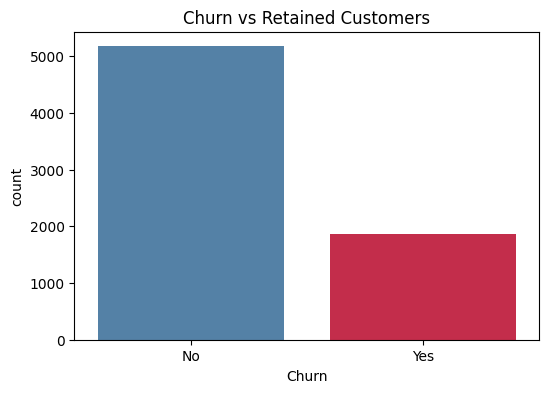

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette=['steelblue','crimson'])
plt.title("Churn vs Retained Customers")
plt.show()

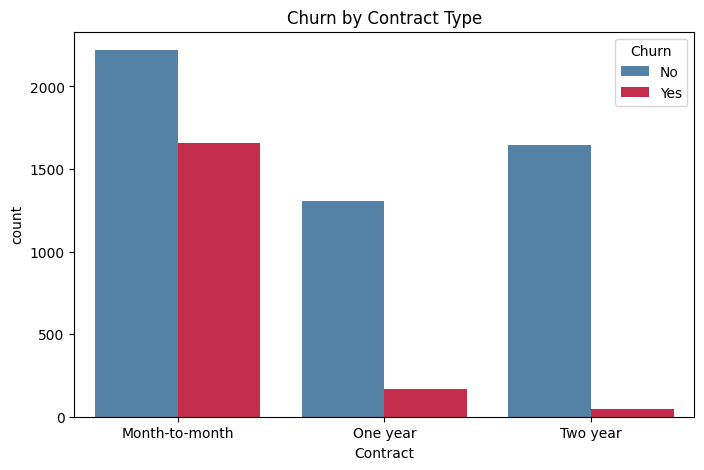

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df,
              palette=['steelblue','crimson'])
plt.title("Churn by Contract Type")
plt.show()

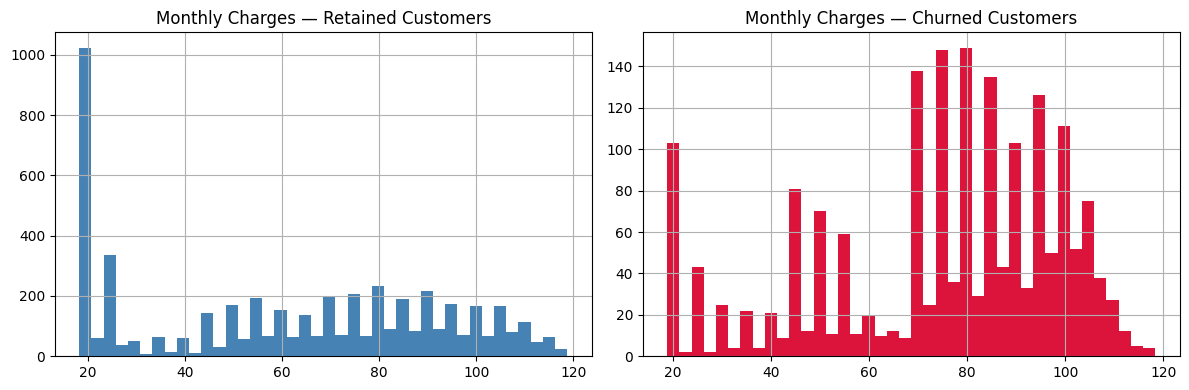

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df[df['Churn']=='No']['MonthlyCharges'].hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title("Monthly Charges — Retained Customers")
df[df['Churn']=='Yes']['MonthlyCharges'].hist(bins=40, ax=axes[1], color='crimson')
axes[1].set_title("Monthly Charges — Churned Customers")
plt.tight_layout()
plt.show()

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_4916\1298589596.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette=['steelblue','crimson'])


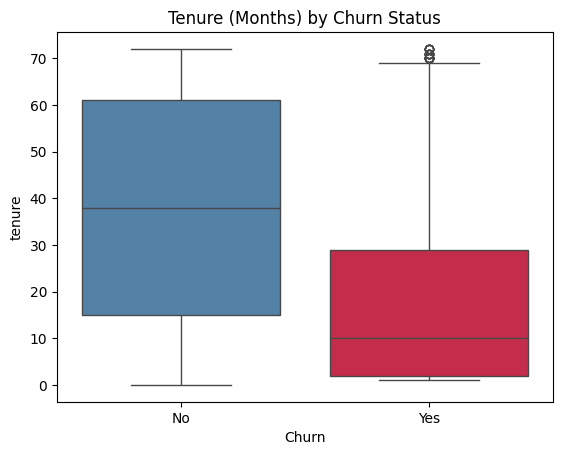

In [9]:
sns.boxplot(x='Churn', y='tenure', data=df, palette=['steelblue','crimson'])
plt.title("Tenure (Months) by Churn Status")
plt.show()

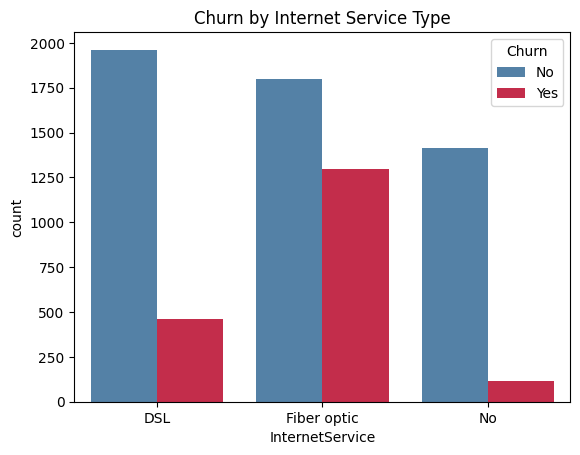

In [10]:
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette=['steelblue','crimson'])
plt.title("Churn by Internet Service Type")
plt.show()

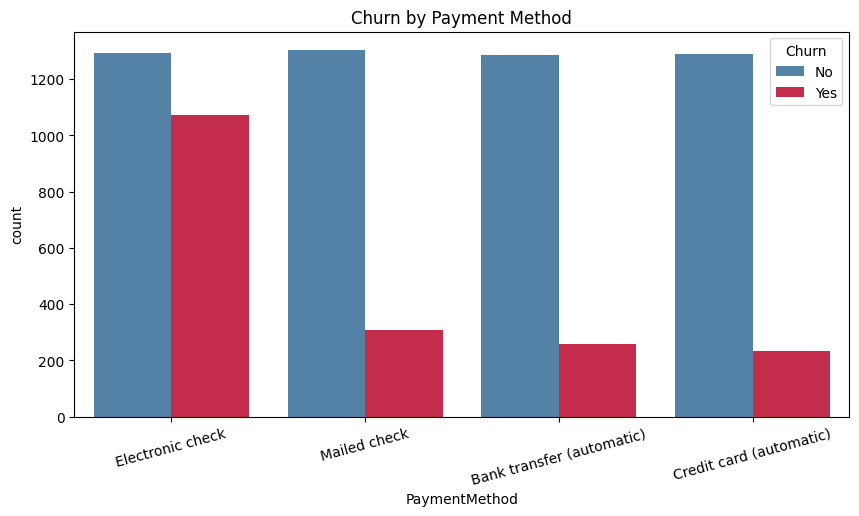

Insight: Electronic check users churn most — possibly disengaged/manual payers


In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df,
              palette=['steelblue','crimson'])
plt.xticks(rotation=15)
plt.title("Churn by Payment Method")
plt.show()
print("Insight: Electronic check users churn most — possibly disengaged/manual payers")

In [16]:
df['Tenure_Group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['New (0-1yr)', 'Growing (1-2yr)',
                                     'Established (2-4yr)', 'Loyal (4+yr)'])
df['HighValue'] = (df['MonthlyCharges'] > 70).astype(int)

services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[services].apply(
    lambda x: x.str.contains('Yes').sum(), axis=1)
df['ChargeRatio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

print("Churn by Tenure Group:")
print(df.groupby('Tenure_Group')['Churn'].value_counts(normalize=True).unstack())

Churn by Tenure Group:
Churn                      No       Yes
Tenure_Group                           
New (0-1yr)          0.523218  0.476782
Growing (1-2yr)      0.712891  0.287109
Established (2-4yr)  0.796110  0.203890
Loyal (4+yr)         0.904868  0.095132


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_4916\122775290.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Tenure_Group')['Churn'].value_counts(normalize=True).unstack())


In [17]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'Churn', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                            'No internet service': 0, 'No phone service': 0})
df = pd.get_dummies(df, columns=['gender', 'InternetService', 'Contract', 'PaymentMethod'],
                    drop_first=True)
df.drop(['customerID', 'Tenure_Group'], axis=1, inplace=True)

print(df.shape) 
print(df.head())

(7043, 27)
   SeniorCitizen  Partner  Dependents  tenure  PhoneService  MultipleLines  \
0              0        1           0       1             0              0   
1              0        0           0      34             1              0   
2              0        0           0       2             1              0   
3              0        0           0      45             0              0   
4              0        0           0       2             1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  ...  \
0               0             1                 0            0  ...   
1               1             0                 1            0  ...   
2               1             1                 0            0  ...   
3               1             0                 1            1  ...   
4               0             0                 0            0  ...   

   ServiceCount  ChargeRatio  gender_Male  InternetService_Fiber optic  \
0             1    

In [22]:
X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
print("=== Logistic Regression ===")
print(classification_report(y_test, lr.predict(X_test),
                             target_names=['Retained', 'Churned']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [21]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42)
rf.fit(X_train, y_train)
print("=== Random Forest ===")
print(classification_report(y_test, rf.predict(X_test),
                             target_names=['Retained', 'Churned']))

=== Random Forest ===
              precision    recall  f1-score   support

    Retained       0.82      0.90      0.86      1035
     Churned       0.63      0.46      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



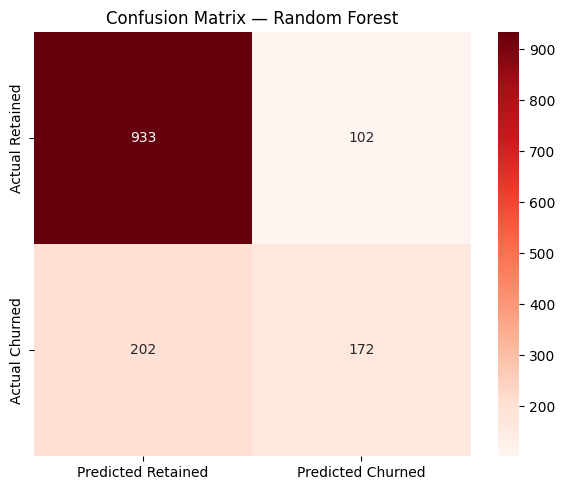

In [20]:
cm = confusion_matrix(y_test, rf.predict(X_test))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'])
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

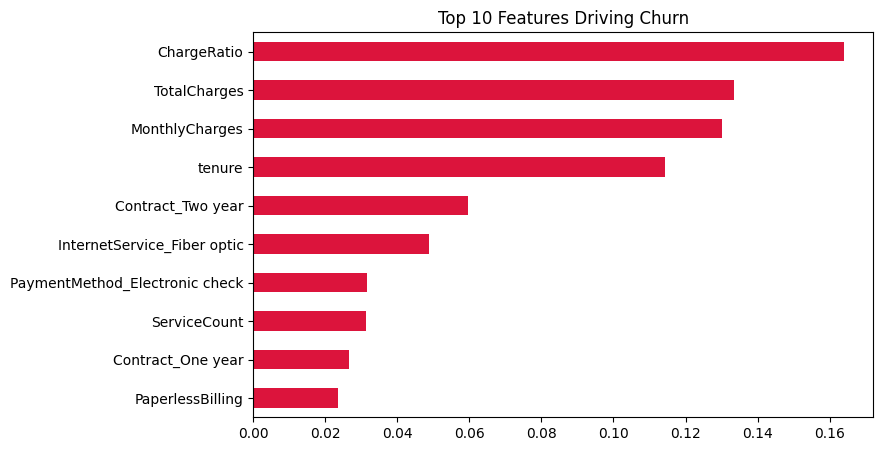

In [19]:
feature_names = df.drop('Churn', axis=1).columns
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(10).plot(kind='barh',
    color='crimson', figsize=(8,5))
plt.title("Top 10 Features Driving Churn")
plt.gca().invert_yaxis()
plt.show()

In [28]:
df_export = pd.read_csv("E:\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_export['TotalCharges'] = pd.to_numeric(df_export['TotalCharges'], errors='coerce').fillna(0)
df_export['Tenure_Group'] = pd.cut(df_export['tenure'],
                                    bins=[0, 12, 24, 48, 72],
                                    labels=['New', 'Growing', 'Established', 'Loyal'])
df_export['ServiceCount'] = df_export[services].apply(
    lambda x: x.str.contains('Yes').sum(), axis=1)
df_export['HighValue'] = (df_export['MonthlyCharges'] > 70).astype(int)

df_export.to_csv("telco_enriched.csv", index=False)

test_ids = df_export.iloc[y_test.index][['customerID']].copy()
test_ids['Actual_Churn'] = y_test.values
test_ids['Predicted_Churn'] = rf.predict(X_test)
test_ids['Churn_Probability'] = rf.predict_proba(X_test)[:, 1]
test_ids.to_csv("model_predictions.csv", index=False)

print("Files saved ")

<>:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<>:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
C:\Users\ELCOT\AppData\Local\Temp\ipykernel_4916\472223470.py:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
  df_export = pd.read_csv("E:\WA_Fn-UseC_-Telco-Customer-Churn.csv")


Files saved 


In [27]:
import sqlite3

conn = sqlite3.connect("churn.db")
df_export.to_sql("telco", conn, if_exists="replace", index=False)
print("Database ready ✅")

Database ready ✅


In [31]:
query1 = """
-- Query 1: Overall churn rate
SELECT Churn,
       COUNT(*) AS total_customers,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM telco
GROUP BY Churn;
"""

result1 = pd.read_sql(query1, conn)

print("=== QUERY 1: Overall churn rate ===")
print(result1)

result1.to_csv('result1_Overall_churn_rate.csv', index=False)
print("Saved✅!")


=== QUERY 1: Overall churn rate ===
  Churn  total_customers  percentage
0    No             5174       73.46
1   Yes             1869       26.54
Saved✅!


In [54]:
query2 = """
-- Query 2:Churn rate by Contract Type
SELECT Contract,
       COUNT(*) AS total,
       SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
       ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM telco
GROUP BY Contract
ORDER BY churn_rate_pct DESC;
"""
result2 = pd.read_sql(query2, conn)
print("=== QUERY 2: Churn rate by Contract Type ===")
print(result2)

result2.to_csv('result2_Churn_rate_by_Contract_Type.csv',
               index=False, encoding='utf-8-sig')
print("Saved✅!")

=== QUERY 2: Churn rate by Contract Type ===
         Contract  total  churned  churn_rate_pct
0  Month-to-month   3875     1655           42.71
1        One year   1473      166           11.27
2        Two year   1695       48            2.83
Saved✅!


In [35]:
query3 = """
-- Query 3: Churn rate by Internet Service
SELECT InternetService,
       COUNT(*) AS total,
       ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM telco
GROUP BY InternetService
ORDER BY churn_rate_pct DESC;
"""

result3 = pd.read_sql(query3, conn)
print("=== QUERY 3:Churn rate by Internet Service ===")
print(result3)

result3.to_csv('result3_Churn_rate_by_Internet_Service.csv', index=False)
print("Saved✅!")

=== QUERY 3:Churn rate by Internet Service ===
  InternetService  total  churn_rate_pct
0     Fiber optic   3096           41.89
1             DSL   2421           18.96
2              No   1526            7.40
Saved✅!


In [36]:
query4 = """
-- Query 4: Average monthly charge for churned vs retained
SELECT Churn,
       ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
       ROUND(AVG(TotalCharges), 2) AS avg_lifetime_value,
       ROUND(AVG(tenure), 1) AS avg_tenure_months
FROM telco
GROUP BY Churn;
"""

result4 = pd.read_sql(query4, conn)
print("=== QUERY 4: Average monthly charge for churned vs retained ===")
print(result4)

result4.to_csv('result4_Average monthly charge for churned vs retained.csv', index=False)
print("Saved✅!")

=== QUERY 4: Average monthly charge for churned vs retained ===
  Churn  avg_monthly  avg_lifetime_value  avg_tenure_months
0    No        61.27             2549.91               37.6
1   Yes        74.44             1531.80               18.0
Saved✅!


In [51]:
query5 = """
-- Query 5: Churn by tenure bucket
SELECT
  CASE
    WHEN tenure <= 12 THEN 'New (0-1yr)'
    WHEN tenure <= 24 THEN 'Growing (1-2yr)'
    WHEN tenure <= 48 THEN 'Established (2-4yr)'
    ELSE 'Loyal (4+yr)'
  END AS tenure_group,
  COUNT(*) AS total,
  SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
  ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM telco
GROUP BY tenure_group
ORDER BY churn_rate_pct DESC;
"""

result5 = pd.read_sql(query5, conn)
print("=== QUERY 5: Churn by tenure bucket ===")
print(result5)

result5.to_csv('result5_Churn by tenure bucket.csv', index=False)
print("Saved✅!")
print("Insight: New customers churn at 48% — the critical onboarding window")

=== QUERY 5: Churn by tenure bucket ===
          tenure_group  total  churned  churn_rate_pct
0          New (0-1yr)   2175     1037           47.68
1      Growing (1-2yr)   1024      294           28.71
2  Established (2-4yr)   1594      325           20.39
3         Loyal (4+yr)   2239      213            9.51
4          New (0-1yr)     11        0            0.00
Saved✅!
Insight: New customers churn at 48% — the critical onboarding window


In [52]:
query6 = """
-- Query 6: High-value customers at risk
SELECT customerID, MonthlyCharges, tenure, Contract, InternetService
FROM telco
WHERE Churn = 'Yes' AND MonthlyCharges > 70
ORDER BY MonthlyCharges DESC
LIMIT 20;
"""

result6 = pd.read_sql(query6, conn)
print("=== QUERY 6: High-value customers at risk ===")
print(result6)

result6.to_csv('result6_High-value customers at risk.csv', index=False)
print("Saved✅!")

=== QUERY 6: High-value customers at risk ===
    customerID  MonthlyCharges  tenure        Contract InternetService
0   8199-ZLLSA          118.35      67        One year     Fiber optic
1   2889-FPWRM          117.80      72        One year     Fiber optic
2   2302-ANTDP          117.45      48  Month-to-month     Fiber optic
3   9053-JZFKV          116.20      67        Two year     Fiber optic
4   1444-VVSGW          115.65      70        One year     Fiber optic
5   0201-OAMXR          115.55      70        One year     Fiber optic
6   4361-BKAXE          114.50      41  Month-to-month     Fiber optic
7   1555-DJEQW          114.20      70        Two year     Fiber optic
8   9158-VCTQB          113.60      41  Month-to-month     Fiber optic
9   7279-BUYWN          113.20      41  Month-to-month     Fiber optic
10  5271-YNWVR          113.15      68        Two year     Fiber optic
11  1583-IHQZE          112.95      12  Month-to-month     Fiber optic
12  5236-PERKL          112.95 

In [53]:
queries = {
    "Churn by Contract": "SELECT Contract, ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS churn_rate FROM telco GROUP BY Contract",
    "Churn by Tenure":   "SELECT CASE WHEN tenure<=12 THEN 'New' WHEN tenure<=24 THEN 'Growing' WHEN tenure<=48 THEN 'Established' ELSE 'Loyal' END AS grp, COUNT(*) as total FROM telco GROUP BY grp"
}
for name, q in queries.items():
    print(f"\n--- {name} ---")
    print(pd.read_sql(q, conn).to_string())


--- Churn by Contract ---
         Contract  churn_rate
0  Month-to-month       42.71
1        One year       11.27
2        Two year        2.83

--- Churn by Tenure ---
           grp  total
0  Established   1594
1      Growing   1024
2        Loyal   2239
3          New   2186


In [56]:
import os
os.makedirs('churn-analysis/sql', exist_ok=True)
with open('churn-analysis/sql/queries.sql', 'w') as f:
    f.write(churn_sql)
print("SQL file created!")


SQL file created!


In [57]:
churn_sql = """
-- ================================================
--  CHURN ANAlYSIS - SQL QUERIES
-- Author: Arshad H R 
-- Date: April 2026
-- Tool: SQLite
-- ================================================

-- Query 1: Overall churn rate
SELECT Churn,
       COUNT(*) AS total_customers,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM telco
GROUP BY Churn;

-- ------------------------------------------------

-- Query 2:Churn rate by Contract Type
SELECT Contract,
       COUNT(*) AS total,
       SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
       ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM telco
GROUP BY Contract
ORDER BY churn_rate_pct DESC;

-- ------------------------------------------------

-- Query 3: Churn rate by Internet Service
SELECT InternetService,
       COUNT(*) AS total,
       ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM telco
GROUP BY InternetService
ORDER BY churn_rate_pct DESC;

-- ------------------------------------------------

-- Query 4: Average monthly charge for churned vs retained
SELECT Churn,
       ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
       ROUND(AVG(TotalCharges), 2) AS avg_lifetime_value,
       ROUND(AVG(tenure), 1) AS avg_tenure_months
FROM telco
GROUP BY Churn;

-- ------------------------------------------------

-- Query 5: Churn by tenure bucket
SELECT
  CASE
    WHEN tenure <= 12 THEN 'New (0-1yr)'
    WHEN tenure <= 24 THEN 'Growing (1-2yr)'
    WHEN tenure <= 48 THEN 'Established (2-4yr)'
    ELSE 'Loyal (4+yr)'
  END AS tenure_group,
  COUNT(*) AS total,
  SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
  ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM telco
GROUP BY tenure_group
ORDER BY churn_rate_pct DESC;

-- ------------------------------------------------

-- Query 6: High-value customers at risk
SELECT customerID, MonthlyCharges, tenure, Contract, InternetService
FROM telco
WHERE Churn = 'Yes' AND MonthlyCharges > 70
ORDER BY MonthlyCharges DESC
LIMIT 20;
"""

with open('churn-analysis/sql/queries.sql', 'w') as f:
    f.write(churn_sql)
print("SQL file created!")

SQL file created!
